### Expermimented with Insightface for KYC Platform (Geldstuck)

This is a face detection and recognition pipeline that uses RetinaFace and InsightFace to detect faces, extract facial landmarks, generate 512-dimensional ArcFace embeddings, and compare faces using cosine similarity to determine whether they belong to the same person.


In [ ]:
!pip install retina-face opencv-python-headless matplotlib

In [ ]:
from retinaface import RetinaFace
import cv2
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]
print("Uploaded:", image_path)

Saving asda.jpg to asda.jpg
Uploaded: asda.jpg


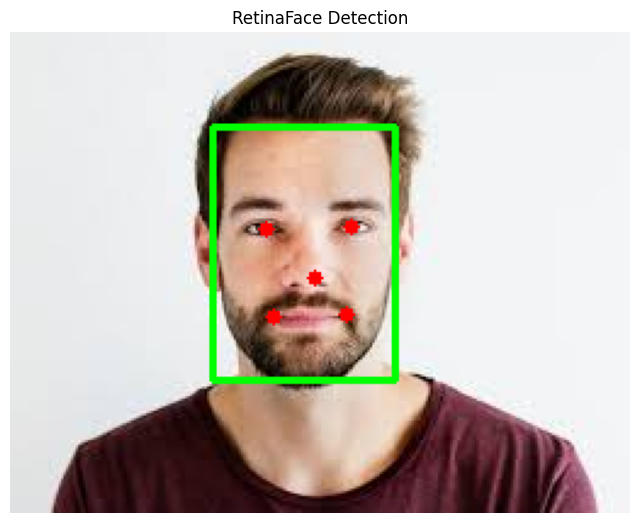

In [ ]:
# Read image
img = cv2.imread(image_path)

# Detect faces
faces = RetinaFace.detect_faces(image_path)

# Draw results
if isinstance(faces, dict):
    for face_id, face_data in faces.items():
        x1, y1, x2, y2 = face_data['facial_area']

        # Draw bounding box
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Draw landmarks
        landmarks = face_data['landmarks']
        for key, point in landmarks.items():
            # Convert float coordinates to integers and then to a tuple
            cv2.circle(img, (int(point[0]), int(point[1])), 3, (0, 0, 255), -1)

# Convert BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show image
plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("RetinaFace Detection")
plt.show()

In [ ]:
faces

{'face_1': {'score': np.float64(0.9984230995178223),
  'facial_area': [np.int64(561), np.int64(151), np.int64(800), np.int64(479)],
  'landmarks': {'right_eye': [np.float32(630.5928), np.float32(280.39972)],
   'left_eye': [np.float32(743.82385), np.float32(275.48)],
   'nose': [np.float32(693.562), np.float32(338.60098)],
   'mouth_right': [np.float32(647.7607), np.float32(401.40616)],
   'mouth_left': [np.float32(736.0995), np.float32(396.13583)]}}}

Embeddings

In [ ]:
!pip install insightface onnxruntime opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 9.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 86.9 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1071487 sha256=5f5a6bc205fa24e6799e88bae2c75ab055e6d4da1ce4b3881f4b85c1f2c7c2b9
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface


In [ ]:
import insightface
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load ArcFace model
app = insightface.app.FaceAnalysis(name='buffalo_l')  # includes detection + ArcFace
app.prepare(ctx_id=0)  # 0 = GPU, -1 = CPU

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:04<00:00, 62863.11KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


In [ ]:
def get_embedding(image_path):
    img = cv2.imread(image_path)

    faces = app.get(img)

    for face in faces:
      print("Bounding Box:", face.bbox)
      print("Landmarks:", face.kps)
      print("Embedding shape:", face.embedding.shape)

    if len(faces) == 0:
        print("No face detected")
        return None

    # Take first face
    embedding = faces[0].embedding  # 512-d vector

    return embedding

In [ ]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


# Example
img1 = "/content/Screenshot 2026-04-08 025625.png"
img2 = "/content/WIN_20260408_02_12_08_Pro.jpg"

emb1 = get_embedding(img1)
emb2 = get_embedding(img2)

if emb1 is not None and emb2 is not None:
    sim = cosine_similarity(emb1, emb2)
    print("Similarity:", sim)

    if sim > 0.6:
        print("✅ Same Person")
    else:
        print("❌ Different Person")

Bounding Box: [397.35806 200.17017 741.91644 634.3506 ]
Landmarks: [[494.56854 359.03397]
 [649.8383  353.59128]
 [576.4027  454.4711 ]
 [521.6967  533.32196]
 [633.2106  528.77313]]
Embedding shape: (512,)
Bounding Box: [562.29517 155.92009 800.3722  467.2471 ]
Landmarks: [[633.8735  274.84662]
 [738.6772  269.67148]
 [692.02924 341.22214]
 [646.9111  391.60782]
 [729.8652  387.49924]]
Embedding shape: (512,)
Similarity: 0.9344976
✅ Same Person


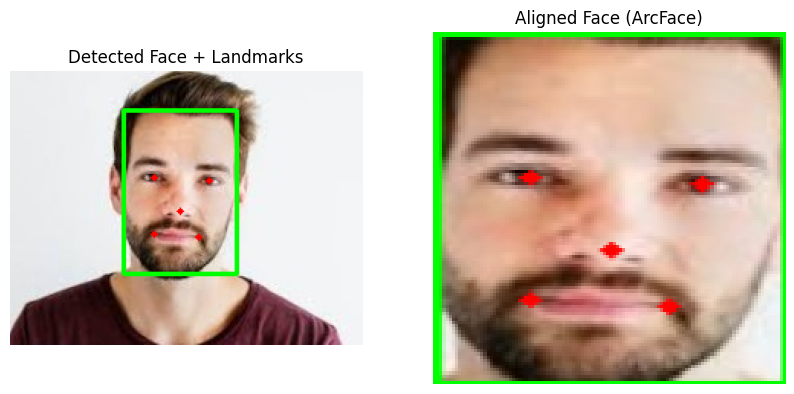

In [ ]:
image_path = "/content/asda.jpg"
img = cv2.imread(image_path)

# Detect faces
faces = app.get(img)

if len(faces) == 0:
    print("No face detected")
else:
    # Take first face
    face = faces[0]

    # Bounding box
    bbox = face.bbox.astype(int)
    x1, y1, x2, y2 = bbox

    # Landmarks
    kps = face.kps.astype(int)

    # Embedding
    embedding = face.embedding  # 512-d vector

    # Draw bbox and landmarks for visualization
    vis = img.copy()
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0,255,0), 2)
    for (x, y) in kps:
        cv2.circle(vis, (x, y), 2, (0,0,255), -1)

    # Crop aligned face (InsightFace does internal alignment, here for display)
    aligned_face = cv2.resize(vis[y1:y2, x1:x2], (112,112))

    # Convert BGR → RGB for matplotlib
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    aligned_rgb = cv2.cvtColor(aligned_face, cv2.COLOR_BGR2RGB)

    # Show images
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(vis_rgb)
    plt.title("Detected Face + Landmarks")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(aligned_rgb)
    plt.title("Aligned Face (ArcFace)")
    plt.axis('off')
    plt.show()